In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.helper_function as hf


In [2]:
FIG_DIR = Path("../Visualization/Analyst")
FIG_DIR.mkdir(parents= True, exist_ok= True)


In [3]:
pay_cols = [f"PAY_{i}" for i in range(1, 7)]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

cols = pay_amt_cols + pay_cols + bill_cols

cols += ['LIMIT_BAL', 'IS_DEFAULT']

df = pd.read_parquet(
    path ="../data/processed/UCI_Credit_Card.parquet",
    columns= cols,
    engine= 'pyarrow'
)

In [4]:
# Ma tran tuong quan - Correlation Matrix
corr_matrix = df[cols].corr()

# Xet tuong quan voi IS_DEFAULT
corr_with_default = corr_matrix['IS_DEFAULT'].sort_values(ascending= True)
print("TQ với DEFAULT:\n", corr_with_default)

TQ với DEFAULT:
 LIMIT_BAL    -0.153520
PAY_AMT1     -0.072929
PAY_AMT2     -0.058579
PAY_AMT4     -0.056827
PAY_AMT3     -0.056250
PAY_AMT5     -0.055124
PAY_AMT6     -0.053183
BILL_AMT1    -0.019644
BILL_AMT2    -0.014193
BILL_AMT3    -0.014076
BILL_AMT4    -0.010156
BILL_AMT5    -0.006760
BILL_AMT6    -0.005372
PAY_6         0.186866
PAY_5         0.204149
PAY_4         0.216614
PAY_3         0.235253
PAY_2         0.263551
PAY_1         0.324794
IS_DEFAULT    1.000000
Name: IS_DEFAULT, dtype: float64


In [5]:
# Xet tuong quan voi LIMIT_BAL
corr_with_limit_bal = corr_matrix['LIMIT_BAL'].sort_values(ascending= True)
print("TQ voi Limit_bal:\n", corr_with_limit_bal)

TQ voi Limit_bal:
 PAY_2        -0.296382
PAY_3        -0.286123
PAY_1        -0.271214
PAY_4        -0.267460
PAY_5        -0.249411
PAY_6        -0.235195
IS_DEFAULT   -0.153520
PAY_AMT2      0.178408
PAY_AMT1      0.195236
PAY_AMT4      0.203242
PAY_AMT3      0.210167
PAY_AMT5      0.217202
PAY_AMT6      0.219595
BILL_AMT2     0.278314
BILL_AMT3     0.283236
BILL_AMT1     0.285430
BILL_AMT6     0.290389
BILL_AMT4     0.293988
BILL_AMT5     0.295562
LIMIT_BAL     1.000000
Name: LIMIT_BAL, dtype: float64


# 1 Phân phối các biến quan trọng theo IS_DEFAULT

## 1.2 Phân phối PAY_1 (Gốc là PAY_0) - Trạng thái thanh toán của tháng gần nhất

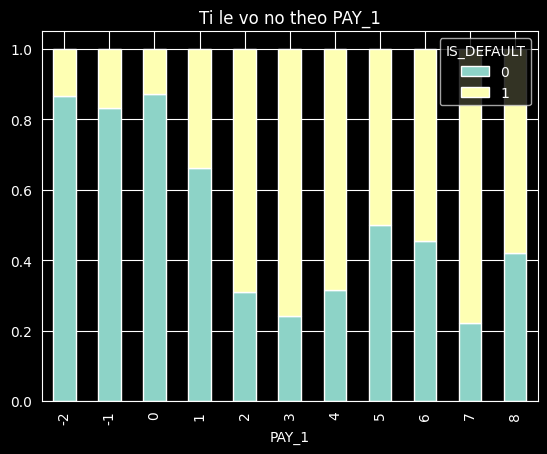

In [6]:
# Phan phoi PAY_1 (Trang thai thanh toan cua thang hien tai)
pd.crosstab(df['PAY_1'], df['IS_DEFAULT'], normalize= 'index').plot(kind= 'bar', stacked= True)

plt.title("Ti le vo no theo PAY_1")
plt.show()

## 1.3 Phân phối LIMIT_BAL theo IS_DEFAULT
- Sử dụng phép toán tích logarit để giảm giá trị của *LIMIT_BAL* thành *log(LIMIT_BAL)*

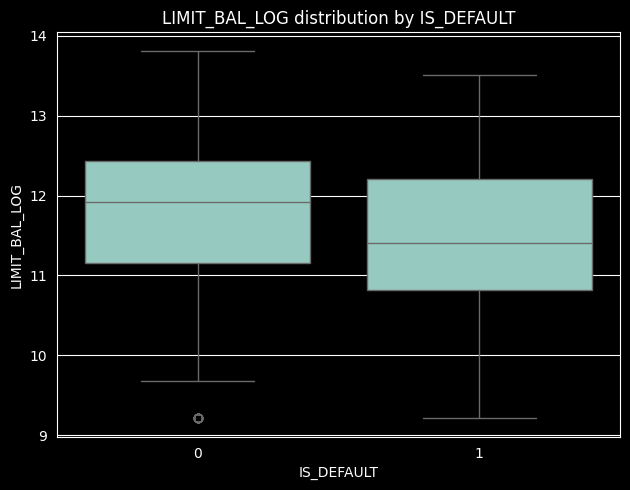

In [7]:
import numpy as np

df['LIMIT_BAL_LOG'] = np.log1p(df['LIMIT_BAL'])

hf.plot_box(df= df, feature= 'LIMIT_BAL_LOG')

## 1.4 Phân phối tổng số dư hóa đơn của tháng gần nhất theo tình trạng vỡ no

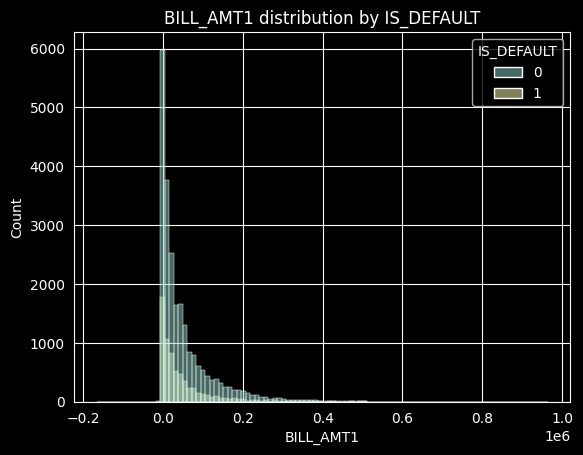

In [8]:

hf.plot_hist(df= df, feature= 'BILL_AMT1', bins= 100)

# 2. Phân tích các chỉ số tài chính từ *LIMIT_BAL* và các chỉ số liên quan
## 2.1 Tỷ lệ sử dụng hạn mức

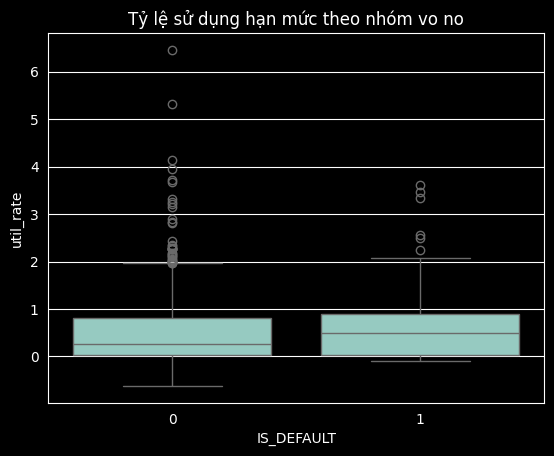

In [9]:
df['util_rate'] = df['BILL_AMT1'] / df['LIMIT_BAL']

sns.boxplot(data= df, x= 'IS_DEFAULT', y= 'util_rate')
plt.title("Tỷ lệ sử dụng hạn mức theo nhóm vo no")

plt.show()


## 2.2 Tỷ lệ thanh toán / hạn mức theo nhóm vỡ nợ

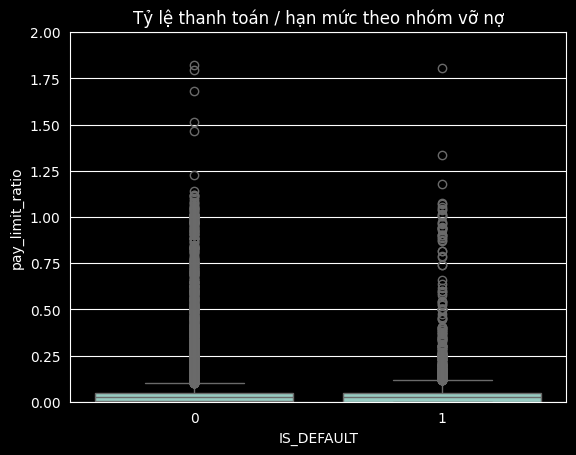

In [10]:
df['pay_limit_ratio'] = df['PAY_AMT1'] / df['LIMIT_BAL']
sns.boxplot(x='IS_DEFAULT', y='pay_limit_ratio', data=df)
plt.ylim(0, 2)
plt.title('Tỷ lệ thanh toán / hạn mức theo nhóm vỡ nợ')
plt.show()

## 2.3 Tỷ lệ thanh toán trên số dư hóa đơn (PAY_AMT1 / BILL_AMT1) – cẩn thận chia cho 0

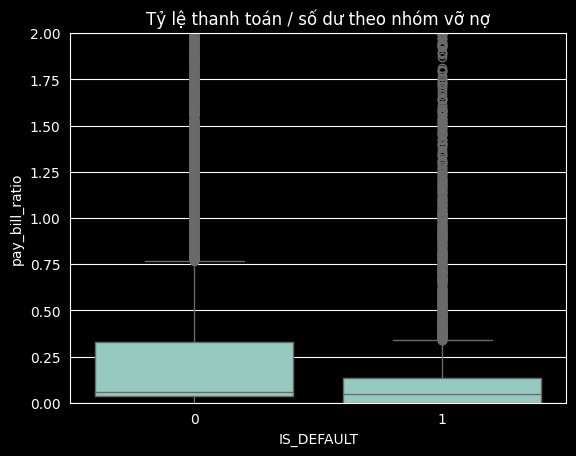

In [11]:
df['pay_bill_ratio'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1e-5)
sns.boxplot(x='IS_DEFAULT', y='pay_bill_ratio', data=df)
plt.ylim(0, 2)
plt.title('Tỷ lệ thanh toán / số dư theo nhóm vỡ nợ')
plt.show()

# 3. Xu huong theo thoi gian
## 3.1 Xu huong so du hoa don

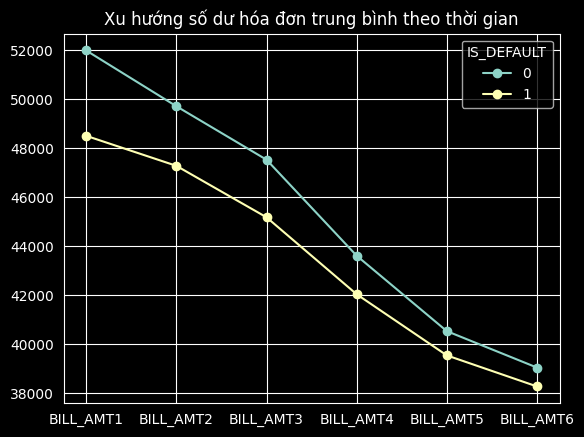

In [12]:
# Lay trung binh so du theo nhom
bill_avg = df.groupby('IS_DEFAULT')[bill_cols].mean().T

bill_avg.plot(marker= 'o')
plt.title('Xu hướng số dư hóa đơn trung bình theo thời gian')
plt.show()

## 3.2 Xu hướng trạng thái thanh toán (PAY_X)

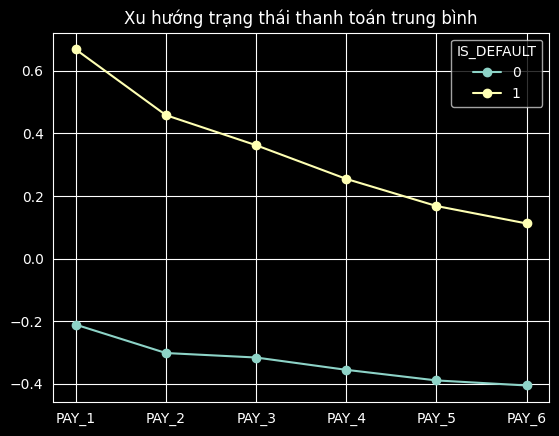

In [13]:
pay_avg = df.groupby('IS_DEFAULT')[pay_cols].mean().T
pay_avg.plot(marker='o')
plt.title('Xu hướng trạng thái thanh toán trung bình')
plt.show()

## 3.3 Xu hướng số tiền thanh toán (PAY_AMT)

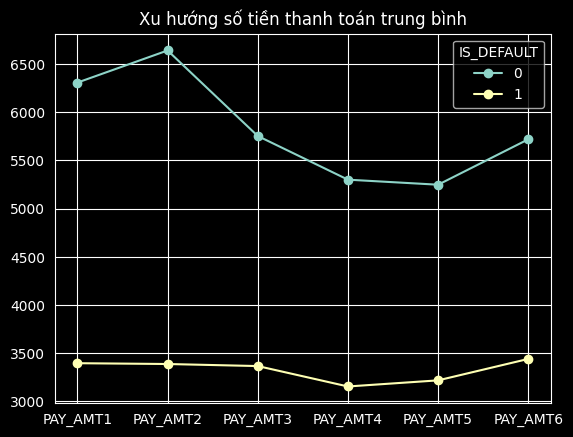

In [14]:
pay_amt_avg = df.groupby('IS_DEFAULT')[pay_amt_cols].mean().T
pay_amt_avg.plot(marker='o')
plt.title('Xu hướng số tiền thanh toán trung bình')
plt.show()

# 4. Tạo các đặc trưng tóm tắt từ các nhóm cột

In [15]:
# Đếm số tháng chậm thanh toán (PAY_X > 0)
df['late_count'] = (df[pay_cols] > 0).sum(axis=1)

# Tổng số tiền thanh toán trong 6 tháng
df['total_paid'] = df[pay_amt_cols].sum(axis=1)

# Tổng số dư hóa đơn
df['total_bill'] = df[bill_cols].sum(axis=1)

# Tỷ lệ thanh toán trên tổng số dư
df['pay_bill_total_ratio'] = df['total_paid'] / (df['total_bill'] + 1e-5)

# Xu hướng số dư (tháng gần nhất so với 6 tháng trước)
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']

# Số tháng liên tiếp chậm thanh toán (đơn giản: kiểm tra PAY_0 > 0 và PAY_2 > 0 ...)
df['consecutive_late'] = (df['PAY_1'] > 0) & (df['PAY_2'] > 0) & (df['PAY_3'] > 0)  # còn có thể cải tiến

# 5. Đánh giá các đặc trưng mới với IS_DEFAULT

In [16]:
new_features = ['late_count', 'total_paid', 'total_bill', 'pay_bill_total_ratio', 'bill_trend', 'consecutive_late']
corr_new = df[new_features + ['IS_DEFAULT']].corr()['IS_DEFAULT'].sort_values(ascending=False)
print(corr_new)

IS_DEFAULT              1.000000
late_count              0.398394
consecutive_late        0.318122
pay_bill_total_ratio   -0.006822
total_bill             -0.012691
bill_trend             -0.025649
total_paid             -0.102354
Name: IS_DEFAULT, dtype: float64
